# 03 Drift Detection and Auto-Retrain Simulation

This notebook simulates a production monitoring loop for NYC taxi demand forecasting. It compares a static LightGBM model trained once on the first 30 days against an adaptive LightGBM model that can retrain when distribution drift or sustained error degradation is detected.

## 0. Imports and Setup

The monitoring workflow uses the same modeling stack as the previous notebook, plus SciPy for drift and significance tests. Paths are relative to the notebook location.

In [1]:
import json
import time
import warnings
from datetime import datetime, timedelta
from pathlib import Path
from typing import Any, Dict, Iterable, List, Tuple

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from scipy.stats import ks_2samp

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

PROJECT_ROOT = Path("..")
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"

TRIP_FILES = [
    RAW_DATA_DIR / "yellow_tripdata_2024-01.parquet",
    RAW_DATA_DIR / "yellow_tripdata_2024-02.parquet",
    RAW_DATA_DIR / "yellow_tripdata_2024-03.parquet",
]

print(f"LightGBM version: {lgb.__version__}")

LightGBM version: 4.6.0


## 1. Load Data and Recreate Feature Set

This section rebuilds the exact feature structure used by `02_ml_modeling.ipynb`: the same raw files, same cleaning rules, same top-20 zone filtering, same lag and rolling definitions, and the same feature column order loaded from `models/feature_columns.json`.

In [2]:
def load_clean_hourly_demand(trip_files: Iterable[Path], zone_path: Path) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Load raw yellow taxi trips, clean pickup timestamps/zones, and aggregate hourly demand."""
    for trip_file in trip_files:
        if not trip_file.exists():
            raise FileNotFoundError(f"Missing trip file: {trip_file.resolve()}")

    zone_lookup_df = pd.read_csv(zone_path).rename(
        columns={"LocationID": "zone_id", "Zone": "zone_name", "Borough": "borough"}
    )
    zone_lookup_df["zone_id"] = zone_lookup_df["zone_id"].astype(int)

    raw_df = pd.concat(
        [
            pd.read_parquet(trip_file, columns=["tpep_pickup_datetime", "PULocationID"])
            for trip_file in trip_files
        ],
        ignore_index=True,
    )
    trip_df = raw_df.copy()
    trip_df["tpep_pickup_datetime"] = pd.to_datetime(
        trip_df["tpep_pickup_datetime"], errors="coerce"
    )
    trip_df = trip_df.dropna(subset=["tpep_pickup_datetime", "PULocationID"])
    trip_df = trip_df[
        (trip_df["tpep_pickup_datetime"] >= pd.Timestamp("2024-01-01"))
        & (trip_df["tpep_pickup_datetime"] < pd.Timestamp("2024-04-01"))
    ].copy()
    trip_df = trip_df[trip_df["PULocationID"] > 0].copy()
    trip_df["PULocationID"] = trip_df["PULocationID"].astype(int)

    hourly_df = (
        trip_df.groupby(["PULocationID", pd.Grouper(key="tpep_pickup_datetime", freq="h")])
        .size()
        .rename("demand")
        .reset_index()
        .rename(columns={"PULocationID": "zone_id", "tpep_pickup_datetime": "observed_timestamp"})
    )
    return hourly_df, zone_lookup_df

In [3]:
def build_feature_table(hourly_df: pd.DataFrame, zone_lookup_df: pd.DataFrame, feature_columns: List[str]) -> Tuple[pd.DataFrame, List[int], float]:
    """Create the top-20-zone hourly modeling panel with the same features as notebook 02."""
    total_demand = hourly_df["demand"].sum()
    zone_volume = (
        hourly_df.groupby("zone_id", as_index=False)["demand"]
        .sum()
        .sort_values("demand", ascending=False)
    )
    top_zone_ids = zone_volume.head(20)["zone_id"].astype(int).tolist()
    top_20_coverage = zone_volume.head(20)["demand"].sum() / total_demand * 100

    hourly_index = pd.date_range("2024-01-01 00:00:00", "2024-03-31 23:00:00", freq="h")
    panel_index = pd.MultiIndex.from_product(
        [top_zone_ids, hourly_index], names=["zone_id", "observed_timestamp"]
    )
    top_hourly = hourly_df[hourly_df["zone_id"].isin(top_zone_ids)].copy()
    panel_df = (
        top_hourly.set_index(["zone_id", "observed_timestamp"])
        .reindex(panel_index, fill_value=0)
        .reset_index()
        .merge(zone_lookup_df[["zone_id", "zone_name", "borough"]], on="zone_id", how="left")
        .sort_values(["zone_id", "observed_timestamp"])
        .reset_index(drop=True)
    )
    return panel_df, top_zone_ids, float(top_20_coverage)

In [4]:
def add_forecasting_features(panel_df: pd.DataFrame) -> pd.DataFrame:
    """Add lag, rolling, temporal, cyclical, borough, and next-hour target columns."""
    featured_df = panel_df.copy()
    zone_group = featured_df.groupby("zone_id")["demand"]

    featured_df["lag_1h"] = zone_group.shift(1)
    featured_df["lag_2h"] = zone_group.shift(2)
    featured_df["lag_3h"] = zone_group.shift(3)
    featured_df["lag_24h"] = zone_group.shift(24)
    featured_df["lag_168h"] = zone_group.shift(168)

    for window, column_name in [(6, "rolling_mean_6h"), (24, "rolling_mean_24h"), (168, "rolling_mean_7d")]:
        featured_df[column_name] = zone_group.transform(
            lambda values, w=window: values.shift(1).rolling(w, min_periods=w).mean()
        )
    featured_df["rolling_std_24h"] = zone_group.transform(
        lambda values: values.shift(1).rolling(24, min_periods=24).std()
    )
    featured_df["rolling_max_24h"] = zone_group.transform(
        lambda values: values.shift(1).rolling(24, min_periods=24).max()
    )
    featured_df["rolling_min_24h"] = zone_group.transform(
        lambda values: values.shift(1).rolling(24, min_periods=24).min()
    )
    return featured_df

In [5]:
def add_time_and_zone_features(featured_df: pd.DataFrame) -> pd.DataFrame:
    """Add forecast timestamp, calendar encodings, borough dummies, and target."""
    featured_df = featured_df.copy()
    featured_df["timestamp"] = featured_df["observed_timestamp"] + pd.Timedelta(hours=1)
    featured_df["hour"] = featured_df["timestamp"].dt.hour
    featured_df["day_of_week"] = featured_df["timestamp"].dt.dayofweek
    featured_df["day_of_month"] = featured_df["timestamp"].dt.day
    featured_df["month"] = featured_df["timestamp"].dt.month
    featured_df["is_weekend"] = featured_df["day_of_week"].isin([5, 6]).astype(int)
    featured_df["is_rush_hour"] = (
        featured_df["day_of_week"].between(0, 4)
        & (featured_df["hour"].between(7, 9) | featured_df["hour"].between(17, 19))
    ).astype(int)

    featured_df["hour_sin"] = np.sin(2 * np.pi * featured_df["hour"] / 24)
    featured_df["hour_cos"] = np.cos(2 * np.pi * featured_df["hour"] / 24)
    featured_df["dow_sin"] = np.sin(2 * np.pi * featured_df["day_of_week"] / 7)
    featured_df["dow_cos"] = np.cos(2 * np.pi * featured_df["day_of_week"] / 7)

    borough_dummies = pd.get_dummies(featured_df["borough"], prefix="borough", dtype=int)
    featured_df = pd.concat([featured_df, borough_dummies], axis=1)
    featured_df["target"] = featured_df.groupby("zone_id")["demand"].shift(-1)
    return featured_df

In [6]:
feature_columns_path = MODELS_DIR / "feature_columns.json"
feature_columns = json.loads(feature_columns_path.read_text(encoding="utf-8"))

hourly_demand, zone_lookup = load_clean_hourly_demand(
    TRIP_FILES, RAW_DATA_DIR / "taxi_zone_lookup.csv"
)
panel_df, top_zone_ids, top_20_coverage = build_feature_table(
    hourly_demand, zone_lookup, feature_columns
)
model_df = add_time_and_zone_features(add_forecasting_features(panel_df))

missing_feature_columns = [column for column in feature_columns if column not in model_df.columns]
if missing_feature_columns:
    raise ValueError(f"Missing feature columns: {missing_feature_columns}")

model_df = model_df.dropna(subset=feature_columns + ["target"]).reset_index(drop=True)
model_df["zone_id"] = model_df["zone_id"].astype(int)
model_df = model_df.sort_values(["timestamp", "zone_id"]).reset_index(drop=True)

print(f"Recreated model table shape: {model_df.shape}")
print(f"Feature count: {len(feature_columns)}")
print(f"Top 20 zone coverage: {top_20_coverage:.2f}%")
print(f"Date range: {model_df['timestamp'].min()} to {model_df['timestamp'].max()}")

Recreated model table shape: (40300, 30)
Feature count: 24
Top 20 zone coverage: 63.05%
Date range: 2024-01-08 01:00:00 to 2024-03-31 23:00:00


## 2. Define Reference Window

The reference window is the first 30 calendar days of 2024. Because the feature table requires a 168-hour lag, usable reference rows begin after the first full week, but the reference definition remains Jan 1 through Jan 30.

In [7]:
REFERENCE_START = pd.Timestamp("2024-01-01")
REFERENCE_END = pd.Timestamp("2024-01-31")
SIMULATION_START = pd.Timestamp("2024-02-01")
SIMULATION_END = pd.Timestamp("2024-04-01")

reference_df = model_df[
    (model_df["timestamp"] >= REFERENCE_START) & (model_df["timestamp"] < REFERENCE_END)
].copy()
simulation_df = model_df[
    (model_df["timestamp"] >= SIMULATION_START) & (model_df["timestamp"] < SIMULATION_END)
].copy()

reference_stats = {
    column: {
        "mean": float(reference_df[column].mean()),
        "std": float(reference_df[column].std()),
        "min": float(reference_df[column].min()),
        "max": float(reference_df[column].max()),
    }
    for column in feature_columns
}

print(f"Reference rows: {len(reference_df):,}")
print(f"Simulation rows: {len(simulation_df):,}")
print(f"Reference range: {reference_df['timestamp'].min()} to {reference_df['timestamp'].max()}")
print(f"Simulation range: {simulation_df['timestamp'].min()} to {simulation_df['timestamp'].max()}")

Reference rows: 11,020
Simulation rows: 28,800
Reference range: 2024-01-08 01:00:00 to 2024-01-30 23:00:00
Simulation range: 2024-02-01 00:00:00 to 2024-03-31 23:00:00


## 3. Drift Detection Functions

PSI and KS tests compare each production window against the reference window. PSI gives a practical stability score, while the KS test provides a hypothesis-test view of distribution shift.

In [8]:
def calculate_psi(reference: Iterable[float], current: Iterable[float], bins: int = 10) -> float:
    """
    Calculate Population Stability Index between two distributions.

    PSI < 0.1: No significant drift
    PSI 0.1-0.2: Moderate drift
    PSI > 0.2: Significant drift

    Args:
        reference: Reference distribution.
        current: Current distribution to compare.
        bins: Number of quantile bins for discretization.

    Returns:
        PSI score.
    """
    reference_values = pd.Series(reference).replace([np.inf, -np.inf], np.nan).dropna().to_numpy(float)
    current_values = pd.Series(current).replace([np.inf, -np.inf], np.nan).dropna().to_numpy(float)
    if len(reference_values) == 0 or len(current_values) == 0:
        return float("nan")

    quantile_edges = np.unique(np.quantile(reference_values, np.linspace(0, 1, bins + 1)))
    if len(quantile_edges) < 3:
        min_value = float(np.min(reference_values))
        max_value = float(np.max(reference_values))
        if min_value == max_value:
            quantile_edges = np.array([min_value - 0.5, min_value + 0.5])
        else:
            quantile_edges = np.linspace(min_value, max_value, bins + 1)

    bin_edges = quantile_edges.copy()
    bin_edges[0] = -np.inf
    bin_edges[-1] = np.inf

    reference_counts, _ = np.histogram(reference_values, bins=bin_edges)
    current_counts, _ = np.histogram(current_values, bins=bin_edges)
    epsilon = 1e-6
    reference_pct = np.maximum(reference_counts / max(reference_counts.sum(), 1), epsilon)
    current_pct = np.maximum(current_counts / max(current_counts.sum(), 1), epsilon)
    psi_value = np.sum((current_pct - reference_pct) * np.log(current_pct / reference_pct))
    return float(psi_value)

In [9]:
def ks_test_drift(reference: Iterable[float], current: Iterable[float]) -> Tuple[float, float, bool]:
    """
    Run a two-sample Kolmogorov-Smirnov test for distribution drift.

    Returns:
        Statistic, p-value, and whether drift is detected at alpha=0.05.
    """
    reference_values = pd.Series(reference).replace([np.inf, -np.inf], np.nan).dropna().to_numpy(float)
    current_values = pd.Series(current).replace([np.inf, -np.inf], np.nan).dropna().to_numpy(float)
    if len(reference_values) == 0 or len(current_values) == 0:
        return float("nan"), float("nan"), False
    statistic, p_value = ks_2samp(reference_values, current_values)
    return float(statistic), float(p_value), bool(p_value < 0.05)

In [10]:
rng = np.random.default_rng(RANDOM_SEED)
synthetic_reference = rng.normal(0, 1, 1000)
synthetic_same = synthetic_reference.copy()
synthetic_shifted = rng.normal(1.5, 1, 1000)

same_psi = calculate_psi(synthetic_reference, synthetic_same)
same_ks_stat, same_ks_p, same_ks_drift = ks_test_drift(synthetic_reference, synthetic_same)
shifted_psi = calculate_psi(synthetic_reference, synthetic_shifted)
shifted_ks_stat, shifted_ks_p, shifted_ks_drift = ks_test_drift(
    synthetic_reference, synthetic_shifted
)

print(f"Same distribution PSI: {same_psi:.4f}, KS p-value: {same_ks_p:.4f}, drift={same_ks_drift}")
print(f"Shifted distribution PSI: {shifted_psi:.4f}, KS p-value: {shifted_ks_p:.4f}, drift={shifted_ks_drift}")

assert same_psi < 0.01
assert same_ks_p > 0.05
assert shifted_psi > 0.2
assert shifted_ks_p < 0.05

Same distribution PSI: 0.0000, KS p-value: 1.0000, drift=False
Shifted distribution PSI: 1.8295, KS p-value: 0.0000, drift=True


## 4. Production Simulation Setup

Production is simulated in chronological 7-day evaluation windows from Feb 1 through Mar 31. Metrics and drift are logged after each week, and any retraining uses only data available before the week-end timestamp.

In [11]:
def mae(y_true: pd.Series, y_pred: pd.Series) -> float:
    """Return mean absolute error."""
    return float((y_true - y_pred).abs().mean())


def rmse(y_true: pd.Series, y_pred: pd.Series) -> float:
    """Return root mean squared error."""
    return float(((y_true - y_pred) ** 2).mean() ** 0.5)


def smape(y_true: pd.Series, y_pred: pd.Series) -> float:
    """Return symmetric mean absolute percentage error as a percentage."""
    denom = (y_true.abs() + y_pred.abs()).replace(0, 1e-8)
    return float((2 * (y_true - y_pred).abs() / denom).mean() * 100)


def wape(y_true: pd.Series, y_pred: pd.Series) -> float:
    """Return weighted absolute percentage error as a percentage."""
    denom = y_true.abs().sum()
    if denom == 0:
        return float("nan")
    return float((y_true - y_pred).abs().sum() / denom * 100)

In [12]:
def compute_metrics(y_true: pd.Series, y_pred: Iterable[float]) -> Dict[str, float]:
    """Compute standard regression metrics for aligned actuals and predictions."""
    prediction_series = pd.Series(np.asarray(y_pred, dtype=float), index=y_true.index)
    prediction_series = prediction_series.clip(lower=0)
    return {
        "mae": mae(y_true, prediction_series),
        "rmse": rmse(y_true, prediction_series),
        "smape": smape(y_true, prediction_series),
        "wape": wape(y_true, prediction_series),
    }


def make_week_windows(start: pd.Timestamp, end: pd.Timestamp) -> List[Tuple[pd.Timestamp, pd.Timestamp]]:
    """Create chronological 7-day windows, with a shorter final window if needed."""
    windows = []
    window_start = start
    while window_start < end:
        window_end = min(window_start + pd.Timedelta(days=7), end)
        windows.append((window_start, window_end))
        window_start = window_end
    return windows

In [13]:
evaluation_windows = make_week_windows(SIMULATION_START, SIMULATION_END)
important_features = ["lag_168h", "hour", "lag_24h", "lag_1h", "zone_id"]

print(f"Simulation windows: {len(evaluation_windows)}")
for index, (week_start, week_end) in enumerate(evaluation_windows, start=1):
    print(f"{index}: {week_start.date()} to {week_end.date()}")

Simulation windows: 9
1: 2024-02-01 to 2024-02-08
2: 2024-02-08 to 2024-02-15
3: 2024-02-15 to 2024-02-22
4: 2024-02-22 to 2024-02-29
5: 2024-02-29 to 2024-03-07
6: 2024-03-07 to 2024-03-14
7: 2024-03-14 to 2024-03-21
8: 2024-03-21 to 2024-03-28
9: 2024-03-28 to 2024-04-01


## 5. Train Initial Static Model

The static model is trained once on the Jan 1-30 reference data and never updated. It represents a deployed model without monitoring or retraining.

In [14]:
def train_lightgbm(train_data: pd.DataFrame, model_features: List[str]) -> Tuple[lgb.LGBMRegressor, float]:
    """Train a LightGBM model with time-ordered internal validation and return duration."""
    if train_data.empty:
        raise ValueError("Training data is empty.")

    ordered_data = train_data.sort_values("timestamp").copy()
    validation_start_index = max(int(len(ordered_data) * 0.80), 1)
    train_part = ordered_data.iloc[:validation_start_index].copy()
    validation_part = ordered_data.iloc[validation_start_index:].copy()
    if validation_part.empty:
        validation_part = train_part

    model = lgb.LGBMRegressor(
        objective="regression",
        metric="rmse",
        num_leaves=63,
        learning_rate=0.05,
        n_estimators=1000,
        max_depth=-1,
        min_child_samples=50,
        feature_fraction=0.9,
        bagging_fraction=0.8,
        random_state=RANDOM_SEED,
        n_jobs=-1,
        verbose=-1,
    )
    start_time = time.perf_counter()
    model.fit(
        train_part[model_features],
        train_part["target"],
        eval_set=[(validation_part[model_features], validation_part["target"])],
        eval_metric="rmse",
        categorical_feature=["zone_id"],
        callbacks=[lgb.early_stopping(50, verbose=False)],
    )
    duration_seconds = time.perf_counter() - start_time
    return model, float(duration_seconds)

In [15]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)
static_model, static_training_duration = train_lightgbm(reference_df, feature_columns)
static_model_path = MODELS_DIR / "static_model.pkl"
joblib.dump(static_model, static_model_path)
print(f"Static model saved to {static_model_path}")
print(f"Static training duration: {static_training_duration:.2f} seconds")

Static model saved to ..\models\static_model.pkl
Static training duration: 2.25 seconds


## 6. Train Initial Adaptive Model

The adaptive model starts from the same reference data as the static model. Later versions will be retrained only if the retrain policy fires.

In [16]:
adaptive_model, adaptive_training_duration = train_lightgbm(reference_df, feature_columns)
adaptive_model_path = MODELS_DIR / "adaptive_model_v1.pkl"
joblib.dump(adaptive_model, adaptive_model_path)

reference_predictions = adaptive_model.predict(reference_df[feature_columns])
BASELINE_REFERENCE_SMAPE = compute_metrics(
    reference_df["target"], reference_predictions
)["smape"]

print(f"Adaptive model v1 saved to {adaptive_model_path}")
print(f"Adaptive training duration: {adaptive_training_duration:.2f} seconds")
print(f"Reference baseline sMAPE: {BASELINE_REFERENCE_SMAPE:.2f}%")

Adaptive model v1 saved to ..\models\adaptive_model_v1.pkl
Adaptive training duration: 1.97 seconds
Reference baseline sMAPE: 18.16%


## 7. Define Retrain Policy

The policy combines error degradation and feature drift signals. It also enforces production constraints: at least 7 days between retrains and no more than 4 retrains in a calendar month.

In [17]:
CURRENT_MONTH_RETRAIN_COUNT = 0


def should_retrain(
    error_history: List[Dict[str, Any]],
    drift_history: List[Dict[str, Any]],
    days_since_retrain: int,
) -> Tuple[bool, str]:
    """
    Decide if the adaptive model should retrain.

    Triggers:
    1. Rolling daily sMAPE increases >= 20% vs baseline for 3+ consecutive days.
    2. PSI > 0.2 for 3+ important features simultaneously.
    3. KS-test p < 0.05 for 3+ features simultaneously.

    Constraints:
    - Minimum 7 days between retrains.
    - Maximum 4 retrains per month.

    Returns:
        Whether to retrain and a human-readable trigger reason.
    """
    if days_since_retrain < 7:
        return False, "minimum 7-day retrain interval not met"
    if CURRENT_MONTH_RETRAIN_COUNT >= 4:
        return False, "monthly retrain cap reached"

    recent_errors = error_history[-3:]
    if len(recent_errors) == 3 and all(
        row["adaptive_smape"] >= BASELINE_REFERENCE_SMAPE * 1.20 for row in recent_errors
    ):
        return True, "adaptive sMAPE >= 20% above reference baseline for 3 consecutive days"

    if drift_history:
        latest_drift = drift_history[-1]
        if latest_drift["psi_alert_feature_count"] >= 3:
            return True, "PSI > 0.2 for 3+ important features"
        if latest_drift["ks_drift_feature_count"] >= 3:
            return True, "KS-test drift for 3+ important features"

    return False, "no retrain trigger"

## 8. Run Production Simulation Loop

Each week is scored with the static and currently deployed adaptive model. Drift is measured against the Jan 1-30 reference distribution. If a retrain fires, the next adaptive version trains on the trailing 30 days ending at the current week boundary.

In [18]:
simulation_results: List[Dict[str, Any]] = []
drift_metric_rows: List[Dict[str, Any]] = []
retrain_event_rows: List[Dict[str, Any]] = []
weekly_prediction_frames: List[pd.DataFrame] = []
drift_history: List[Dict[str, Any]] = []
daily_error_history: List[Dict[str, Any]] = []

adaptive_model_version = 1
last_retrain_timestamp = REFERENCE_END
current_retrain_month = None
CURRENT_MONTH_RETRAIN_COUNT = 0

In [19]:
for week_number, (week_start, week_end) in enumerate(evaluation_windows, start=1):
    week_data = model_df[
        (model_df["timestamp"] >= week_start) & (model_df["timestamp"] < week_end)
    ].copy()
    if week_data.empty:
        print(f"Week {week_number}/{len(evaluation_windows)} skipped: no rows.")
        continue

    static_pred = np.clip(static_model.predict(week_data[feature_columns]), 0, None)
    adaptive_pred = np.clip(adaptive_model.predict(week_data[feature_columns]), 0, None)
    actuals = week_data["target"]

    static_metrics = compute_metrics(actuals, static_pred)
    adaptive_metrics = compute_metrics(actuals, adaptive_pred)

    prediction_output = week_data[
        ["timestamp", "zone_id", "zone_name", "borough", "target", "hour", "day_of_week", "is_weekend", "is_rush_hour"]
    ].rename(columns={"target": "actual_demand"})
    prediction_output["static_prediction"] = static_pred
    prediction_output["adaptive_prediction"] = adaptive_pred
    prediction_output["model_version"] = f"adaptive_v{adaptive_model_version}"
    weekly_prediction_frames.append(prediction_output)

    for day, day_data in prediction_output.groupby(prediction_output["timestamp"].dt.date):
        daily_error_history.append(
            {
                "date": pd.Timestamp(day),
                "adaptive_smape": smape(day_data["actual_demand"], day_data["adaptive_prediction"]),
                "static_smape": smape(day_data["actual_demand"], day_data["static_prediction"]),
            }
        )

    drift_scores: Dict[str, Dict[str, Any]] = {}
    psi_alert_count = 0
    ks_drift_count = 0
    for feature in important_features:
        psi_value = calculate_psi(reference_df[feature], week_data[feature])
        ks_stat, ks_p, ks_drift = ks_test_drift(reference_df[feature], week_data[feature])
        drift_scores[feature] = {
            "psi": psi_value,
            "ks_stat": ks_stat,
            "ks_p": ks_p,
            "ks_drift": ks_drift,
        }
        psi_alert_count += int(psi_value > 0.2)
        ks_drift_count += int(ks_drift)
        drift_metric_rows.append(
            {
                "week_start": week_start,
                "week_end": week_end,
                "feature": feature,
                "psi": psi_value,
                "ks_statistic": ks_stat,
                "ks_p_value": ks_p,
                "drift_detected": ks_drift,
            }
        )

    drift_history.append(
        {
            "week_start": week_start,
            "psi_alert_feature_count": psi_alert_count,
            "ks_drift_feature_count": ks_drift_count,
            "average_psi": float(np.nanmean([v["psi"] for v in drift_scores.values()])),
        }
    )

    if current_retrain_month != week_end.month:
        current_retrain_month = week_end.month
        CURRENT_MONTH_RETRAIN_COUNT = 0

    days_since_retrain = int((week_end - last_retrain_timestamp).days)
    retrain_now, retrain_reason = should_retrain(
        daily_error_history, drift_history, days_since_retrain
    )
    model_version_used = f"adaptive_v{adaptive_model_version}"

    simulation_results.append(
        {
            "week_start": week_start,
            "week_end": week_end,
            "static_mae": static_metrics["mae"],
            "static_rmse": static_metrics["rmse"],
            "static_smape": static_metrics["smape"],
            "static_wape": static_metrics["wape"],
            "adaptive_mae": adaptive_metrics["mae"],
            "adaptive_rmse": adaptive_metrics["rmse"],
            "adaptive_smape": adaptive_metrics["smape"],
            "adaptive_wape": adaptive_metrics["wape"],
            "drift_psi_scores": {k: v["psi"] for k, v in drift_scores.items()},
            "ks_test_results": {k: {"ks_stat": v["ks_stat"], "ks_p": v["ks_p"], "ks_drift": v["ks_drift"]} for k, v in drift_scores.items()},
            "retrain_triggered": retrain_now,
            "retrain_reason": retrain_reason if retrain_now else None,
            "model_version": model_version_used,
        }
    )

    if retrain_now:
        train_start = week_end - pd.Timedelta(days=30)
        retrain_data = model_df[
            (model_df["timestamp"] >= train_start) & (model_df["timestamp"] < week_end)
        ].copy()
        adaptive_model_version += 1
        adaptive_model, retrain_duration = train_lightgbm(retrain_data, feature_columns)
        last_retrain_timestamp = week_end
        CURRENT_MONTH_RETRAIN_COUNT += 1

        event_row = {
            "timestamp": week_end,
            "trigger_reason": retrain_reason,
            "model_version": f"adaptive_v{adaptive_model_version}",
            "training_data_size": int(len(retrain_data)),
            "training_duration_seconds": retrain_duration,
        }
        retrain_event_rows.append(event_row)
        joblib.dump(adaptive_model, MODELS_DIR / f"adaptive_model_v{adaptive_model_version}.pkl")

    print(
        f"Week {week_number}/{len(evaluation_windows)} processed: "
        f"static sMAPE={static_metrics['smape']:.2f}%, "
        f"adaptive sMAPE={adaptive_metrics['smape']:.2f}%, "
        f"retrain={retrain_now}"
    )

Week 1/9 processed: static sMAPE=25.26%, adaptive sMAPE=25.26%, retrain=True


Week 2/9 processed: static sMAPE=26.78%, adaptive sMAPE=25.56%, retrain=True


Week 3/9 processed: static sMAPE=25.74%, adaptive sMAPE=26.43%, retrain=True


Week 4/9 processed: static sMAPE=25.81%, adaptive sMAPE=26.21%, retrain=True


Week 5/9 processed: static sMAPE=25.44%, adaptive sMAPE=22.97%, retrain=True


Week 6/9 processed: static sMAPE=26.57%, adaptive sMAPE=24.26%, retrain=True


Week 7/9 processed: static sMAPE=25.48%, adaptive sMAPE=23.78%, retrain=True


Week 8/9 processed: static sMAPE=26.00%, adaptive sMAPE=23.18%, retrain=True
Week 9/9 processed: static sMAPE=26.76%, adaptive sMAPE=25.42%, retrain=False


In [20]:
simulation_results_df = pd.DataFrame(simulation_results)
drift_metrics_df = pd.DataFrame(drift_metric_rows)
retrain_events_df = pd.DataFrame(
    retrain_event_rows,
    columns=[
        "timestamp",
        "trigger_reason",
        "model_version",
        "training_data_size",
        "training_duration_seconds",
    ],
)
weekly_predictions_df = pd.concat(weekly_prediction_frames, ignore_index=True)

display(simulation_results_df[[
    "week_start", "week_end", "static_smape", "adaptive_smape", "retrain_triggered", "model_version"
]].round(3))
display(retrain_events_df)

C:\Users\Samahitha CM\AppData\Local\Temp\ipykernel_29312\2468763930.py:17: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ]].round(3))


,week_start,week_end,static_smape,adaptive_smape,retrain_triggered,model_version
0,2024-02-01,2024-02-08,25.256,25.256,True,adaptive_v1
1,2024-02-08,2024-02-15,26.782,25.556,True,adaptive_v2
2,2024-02-15,2024-02-22,25.745,26.430,True,adaptive_v3
3,2024-02-22,2024-02-29,25.810,26.206,True,adaptive_v4
4,2024-02-29,2024-03-07,25.443,22.969,True,adaptive_v5
5,2024-03-07,2024-03-14,26.567,24.257,True,adaptive_v6
6,2024-03-14,2024-03-21,25.475,23.780,True,adaptive_v7
7,2024-03-21,2024-03-28,26.000,23.179,True,adaptive_v8
8,2024-03-28,2024-04-01,26.755,25.424,False,adaptive_v9


,timestamp,trigger_reason,model_version,training_data_size,training_duration_seconds
0,2024-02-08,adaptive sMAPE >= 20% above reference baseline...,adaptive_v2,14400,2.395803
1,2024-02-15,adaptive sMAPE >= 20% above reference baseline...,adaptive_v3,14400,1.814189
2,2024-02-22,adaptive sMAPE >= 20% above reference baseline...,adaptive_v4,14400,2.619893
3,2024-02-29,adaptive sMAPE >= 20% above reference baseline...,adaptive_v5,14400,4.506493
4,2024-03-07,adaptive sMAPE >= 20% above reference baseline...,adaptive_v6,14400,1.289525
5,2024-03-14,adaptive sMAPE >= 20% above reference baseline...,adaptive_v7,14400,0.713818
6,2024-03-21,adaptive sMAPE >= 20% above reference baseline...,adaptive_v8,14400,2.562154
7,2024-03-28,KS-test drift for 3+ important features,adaptive_v9,14400,2.191536


## 9. Visualizations

The monitoring plots show where drift appears, when adaptive retraining happens, and whether those retrains improve forecast error relative to the static model.

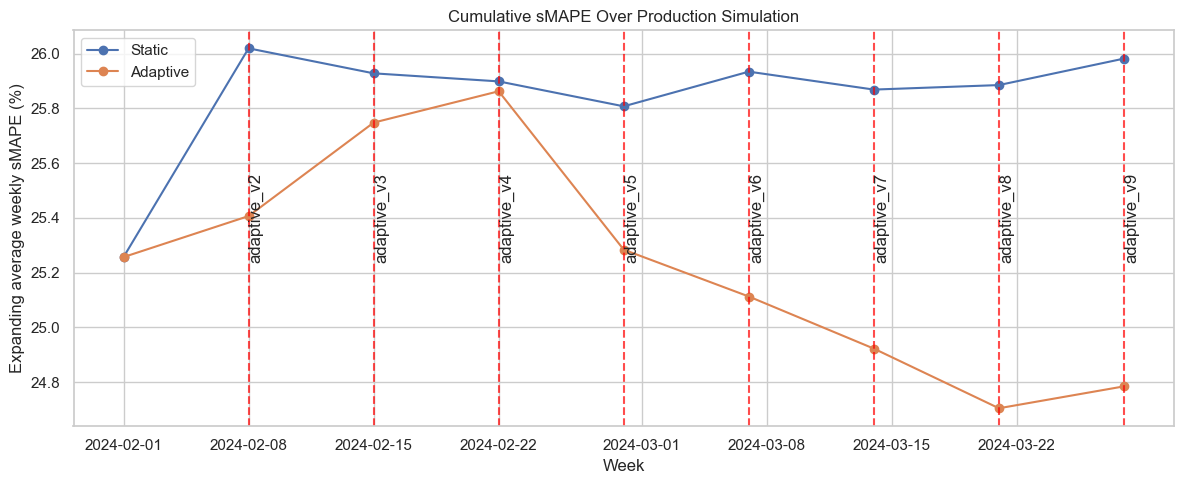

In [21]:
plot_results = simulation_results_df.copy()
plot_results["week_label"] = plot_results["week_start"].dt.strftime("%b %d")
plot_results["static_cumulative_smape"] = plot_results["static_smape"].expanding().mean()
plot_results["adaptive_cumulative_smape"] = plot_results["adaptive_smape"].expanding().mean()

plt.figure(figsize=(12, 5))
plt.plot(plot_results["week_start"], plot_results["static_cumulative_smape"], marker="o", label="Static")
plt.plot(plot_results["week_start"], plot_results["adaptive_cumulative_smape"], marker="o", label="Adaptive")
for _, event in retrain_events_df.iterrows():
    plt.axvline(event["timestamp"], color="red", linestyle="--", alpha=0.7)
    plt.text(event["timestamp"], plt.ylim()[1] * 0.98, event["model_version"], rotation=90, va="top")
plt.title("Cumulative sMAPE Over Production Simulation")
plt.xlabel("Week")
plt.ylabel("Expanding average weekly sMAPE (%)")
plt.legend()
plt.tight_layout()
plt.show()

The cumulative error plot is the main production comparison: lower cumulative sMAPE means the model strategy is aging better across the simulated deployment period.

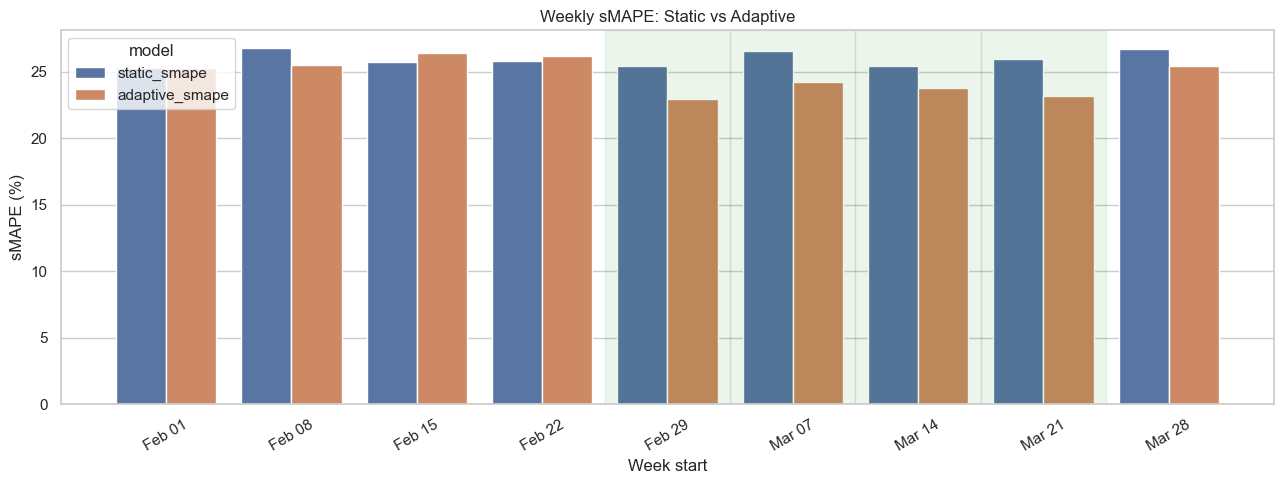

In [22]:
weekly_smape_plot = plot_results[["week_label", "static_smape", "adaptive_smape"]].melt(
    id_vars="week_label", var_name="model", value_name="smape"
)
adaptive_win_labels = set(
    plot_results.loc[plot_results["adaptive_smape"] < plot_results["static_smape"] * 0.95, "week_label"]
)

plt.figure(figsize=(13, 5))
ax = sns.barplot(data=weekly_smape_plot, x="week_label", y="smape", hue="model")
for index, week_label in enumerate(plot_results["week_label"]):
    if week_label in adaptive_win_labels:
        ax.axvspan(index - 0.5, index + 0.5, color="green", alpha=0.08)
plt.title("Weekly sMAPE: Static vs Adaptive")
plt.xlabel("Week start")
plt.ylabel("sMAPE (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Green shading marks weeks where adaptive sMAPE is at least 5% lower than static sMAPE, highlighting periods where monitoring and retraining paid off.

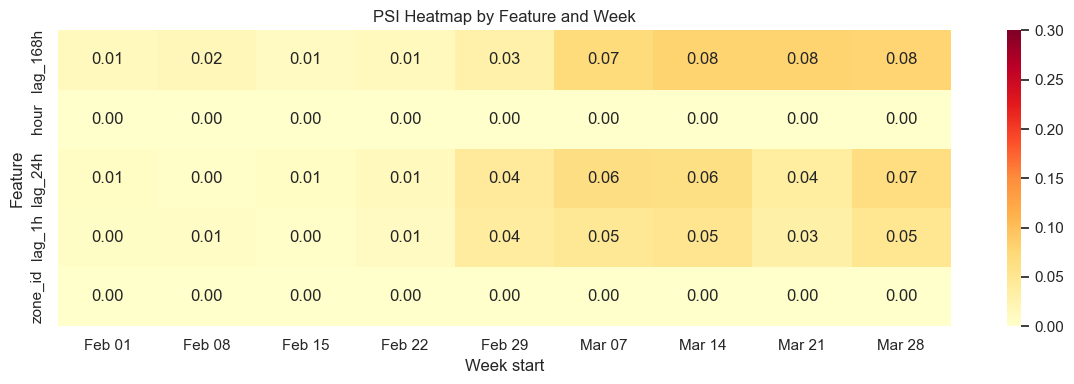

In [23]:
drift_heatmap = drift_metrics_df.copy()
drift_heatmap["week_label"] = drift_heatmap["week_start"].dt.strftime("%b %d")
drift_pivot = drift_heatmap.pivot(index="feature", columns="week_label", values="psi").loc[important_features]

plt.figure(figsize=(12, 4))
sns.heatmap(drift_pivot, annot=True, fmt=".2f", cmap="YlOrRd", vmin=0, vmax=max(0.3, drift_pivot.max().max()))
plt.title("PSI Heatmap by Feature and Week")
plt.xlabel("Week start")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

PSI values above 0.2 indicate significant drift. The heatmap makes it clear which model inputs are moving away from the Jan 1-30 reference distribution.

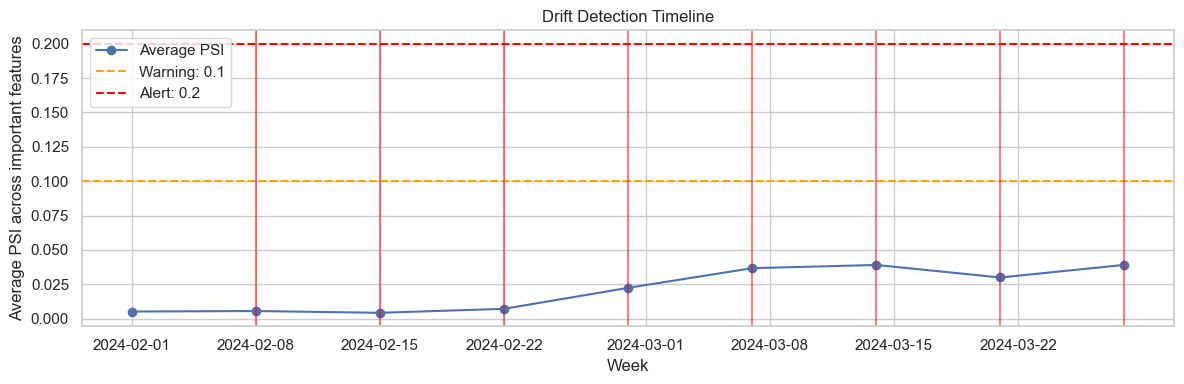

In [24]:
avg_psi_by_week = drift_metrics_df.groupby("week_start", as_index=False)["psi"].mean()

plt.figure(figsize=(12, 4))
plt.plot(avg_psi_by_week["week_start"], avg_psi_by_week["psi"], marker="o", label="Average PSI")
plt.axhline(0.1, color="orange", linestyle="--", label="Warning: 0.1")
plt.axhline(0.2, color="red", linestyle="--", label="Alert: 0.2")
for _, event in retrain_events_df.iterrows():
    plt.axvline(event["timestamp"], color="red", alpha=0.5)
plt.title("Drift Detection Timeline")
plt.xlabel("Week")
plt.ylabel("Average PSI across important features")
plt.legend()
plt.tight_layout()
plt.show()

The timeline summarizes drift pressure across important features and shows whether retrain events line up with warning or alert periods.

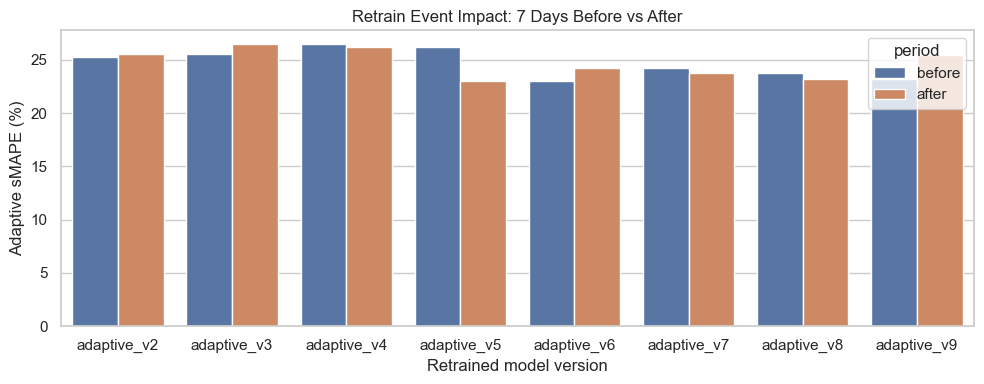

In [25]:
impact_rows = []
for _, event in retrain_events_df.iterrows():
    event_time = pd.Timestamp(event["timestamp"])
    before = weekly_predictions_df[
        (weekly_predictions_df["timestamp"] >= event_time - pd.Timedelta(days=7))
        & (weekly_predictions_df["timestamp"] < event_time)
    ]
    after = weekly_predictions_df[
        (weekly_predictions_df["timestamp"] >= event_time)
        & (weekly_predictions_df["timestamp"] < event_time + pd.Timedelta(days=7))
    ]
    if not before.empty:
        impact_rows.append({"model_version": event["model_version"], "period": "before", "adaptive_smape": smape(before["actual_demand"], before["adaptive_prediction"])})
    if not after.empty:
        impact_rows.append({"model_version": event["model_version"], "period": "after", "adaptive_smape": smape(after["actual_demand"], after["adaptive_prediction"])})

impact_df = pd.DataFrame(impact_rows)
if impact_df.empty:
    print("No retrain events with before/after windows were available for impact plotting.")
else:
    plt.figure(figsize=(10, 4))
    sns.barplot(data=impact_df, x="model_version", y="adaptive_smape", hue="period")
    plt.title("Retrain Event Impact: 7 Days Before vs After")
    plt.xlabel("Retrained model version")
    plt.ylabel("Adaptive sMAPE (%)")
    plt.tight_layout()
    plt.show()

The before/after view checks whether retraining is followed by a practical reduction in adaptive model error over the next available week.

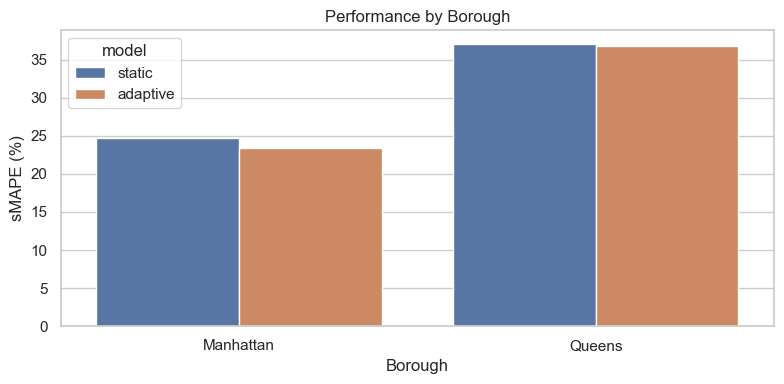

In [26]:
def grouped_smape(frame: pd.DataFrame, group_column: str) -> pd.DataFrame:
    """Compute static and adaptive sMAPE by a categorical grouping column."""
    rows = []
    for group_value, group_df in frame.groupby(group_column):
        rows.append({"group": group_value, "model": "static", "smape": smape(group_df["actual_demand"], group_df["static_prediction"])})
        rows.append({"group": group_value, "model": "adaptive", "smape": smape(group_df["actual_demand"], group_df["adaptive_prediction"])})
    return pd.DataFrame(rows)


borough_performance = grouped_smape(weekly_predictions_df, "borough")
plt.figure(figsize=(8, 4))
sns.barplot(data=borough_performance, x="group", y="smape", hue="model")
plt.title("Performance by Borough")
plt.xlabel("Borough")
plt.ylabel("sMAPE (%)")
plt.tight_layout()
plt.show()

Borough-level performance shows whether the adaptive policy helps consistently across Manhattan and Queens or only in one geography.

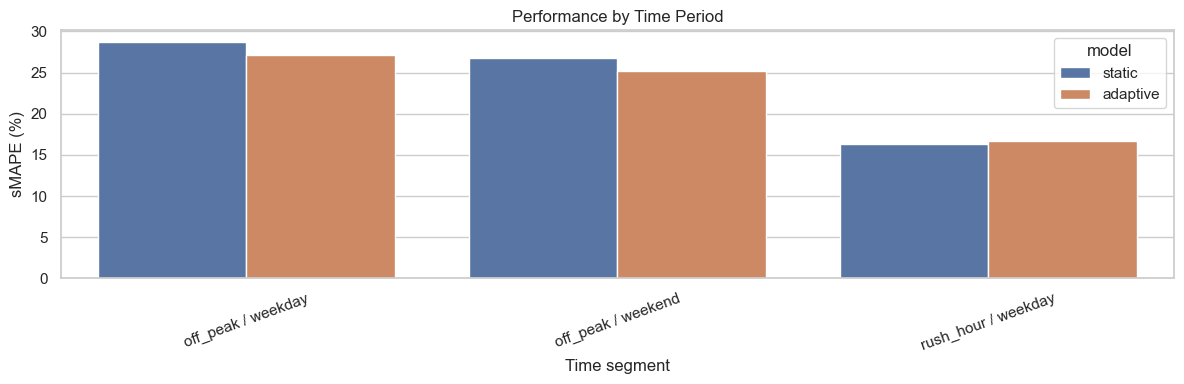

In [27]:
period_predictions = weekly_predictions_df.copy()
period_predictions["rush_period"] = np.where(period_predictions["is_rush_hour"] == 1, "rush_hour", "off_peak")
period_predictions["week_part"] = np.where(period_predictions["is_weekend"] == 1, "weekend", "weekday")
period_predictions["period_segment"] = period_predictions["rush_period"] + " / " + period_predictions["week_part"]

period_performance = grouped_smape(period_predictions, "period_segment")
plt.figure(figsize=(12, 4))
sns.barplot(data=period_performance, x="group", y="smape", hue="model")
plt.title("Performance by Time Period")
plt.xlabel("Time segment")
plt.ylabel("sMAPE (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Time-period performance separates rush-hour and weekend behavior, which are common sources of operational forecast risk.

## 10. Statistical Significance Test

A paired one-sided t-test compares weekly sMAPE values. The null hypothesis is equal performance; the alternative is that static weekly sMAPE is greater than adaptive weekly sMAPE.

In [28]:
static_weekly_smape = simulation_results_df["static_smape"]
adaptive_weekly_smape = simulation_results_df["adaptive_smape"]
t_statistic, p_value = stats.ttest_rel(
    static_weekly_smape, adaptive_weekly_smape, alternative="greater"
)
reject_null = bool(p_value < 0.05)

print(f"Mean static weekly sMAPE: {static_weekly_smape.mean():.2f}%")
print(f"Mean adaptive weekly sMAPE: {adaptive_weekly_smape.mean():.2f}%")
print(f"T-statistic: {t_statistic:.4f}")
print(f"One-sided p-value: {p_value:.4f}")
print("Conclusion:", "Reject H0; adaptive is significantly better." if reject_null else "Fail to reject H0; improvement is not statistically significant.")

Mean static weekly sMAPE: 25.98%
Mean adaptive weekly sMAPE: 24.78%
T-statistic: 2.7873
One-sided p-value: 0.0118
Conclusion: Reject H0; adaptive is significantly better.


## 11. Save Results

The monitoring outputs are saved as production-style artifacts: weekly simulation metrics, detailed drift metrics, retrain events, row-level predictions, and the final adaptive model.

In [29]:
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

simulation_results_for_csv = simulation_results_df.copy()
simulation_results_for_csv["drift_psi_scores"] = simulation_results_for_csv["drift_psi_scores"].apply(json.dumps)
simulation_results_for_csv["ks_test_results"] = simulation_results_for_csv["ks_test_results"].apply(json.dumps)

simulation_results_path = PROCESSED_DATA_DIR / "simulation_results.csv"
drift_metrics_path = PROCESSED_DATA_DIR / "drift_metrics.csv"
retrain_events_path = PROCESSED_DATA_DIR / "retrain_events.csv"
weekly_predictions_path = PROCESSED_DATA_DIR / "weekly_predictions.csv"
final_adaptive_model_path = MODELS_DIR / "adaptive_model_final.pkl"

simulation_results_for_csv.to_csv(simulation_results_path, index=False)
drift_metrics_df.to_csv(drift_metrics_path, index=False)
retrain_events_df.to_csv(retrain_events_path, index=False)
weekly_predictions_df[
    [
        "timestamp",
        "zone_id",
        "zone_name",
        "borough",
        "actual_demand",
        "static_prediction",
        "adaptive_prediction",
        "model_version",
    ]
].to_csv(weekly_predictions_path, index=False)
joblib.dump(adaptive_model, final_adaptive_model_path)

print(f"Saved {simulation_results_path}")
print(f"Saved {drift_metrics_path}")
print(f"Saved {retrain_events_path}")
print(f"Saved {weekly_predictions_path}")
print(f"Saved {final_adaptive_model_path}")

Saved ..\data\processed\simulation_results.csv
Saved ..\data\processed\drift_metrics.csv
Saved ..\data\processed\retrain_events.csv
Saved ..\data\processed\weekly_predictions.csv
Saved ..\models\adaptive_model_final.pkl


In [30]:
required_outputs = [
    simulation_results_path,
    drift_metrics_path,
    retrain_events_path,
    weekly_predictions_path,
    static_model_path,
    adaptive_model_path,
    final_adaptive_model_path,
]
for output_path in required_outputs:
    assert output_path.exists(), f"Missing output: {output_path}"

expected_prediction_columns = [
    "timestamp",
    "zone_id",
    "zone_name",
    "borough",
    "actual_demand",
    "static_prediction",
    "adaptive_prediction",
    "model_version",
]
saved_predictions = pd.read_csv(weekly_predictions_path)
assert saved_predictions.columns.tolist() == expected_prediction_columns
print("Output verification passed.")

Output verification passed.


## 12. Summary Statistics

The final summary condenses retrain behavior, average error, significance testing, and the best/worst adaptive weeks.

In [31]:
static_avg_smape = float(simulation_results_df["static_smape"].mean())
adaptive_avg_smape = float(simulation_results_df["adaptive_smape"].mean())
improvement_pct = (static_avg_smape - adaptive_avg_smape) / static_avg_smape * 100
simulation_duration_weeks = len(simulation_results_df)
retrain_count = len(retrain_events_df)

comparison_df = simulation_results_df.copy()
comparison_df["adaptive_improvement_pct"] = (
    (comparison_df["static_smape"] - comparison_df["adaptive_smape"])
    / comparison_df["static_smape"]
    * 100
)
best_week = comparison_df.sort_values("adaptive_improvement_pct", ascending=False).iloc[0]
worst_week = comparison_df.sort_values("adaptive_improvement_pct").iloc[0]

summary_table = pd.DataFrame(
    [
        {"metric": "simulation_duration_weeks", "value": simulation_duration_weeks},
        {"metric": "retrain_events", "value": retrain_count},
        {"metric": "static_avg_weekly_smape", "value": static_avg_smape},
        {"metric": "adaptive_avg_weekly_smape", "value": adaptive_avg_smape},
        {"metric": "improvement_pct", "value": improvement_pct},
        {"metric": "paired_t_test_p_value", "value": float(p_value)},
        {"metric": "best_adaptive_week_start", "value": best_week["week_start"]},
        {"metric": "worst_adaptive_week_start", "value": worst_week["week_start"]},
    ]
)
display(summary_table)

print(f"Total simulation duration: {simulation_duration_weeks} weeks (Feb-Mar 2024)")
print(f"Number of retrain events: {retrain_count}")
print("Retrain triggers:", retrain_events_df["trigger_reason"].tolist())
print(f"Static model average weekly sMAPE: {static_avg_smape:.2f}%")
print(f"Adaptive model average weekly sMAPE: {adaptive_avg_smape:.2f}%")
print(f"Improvement: {improvement_pct:.2f}%")
print(f"Statistical significance p-value: {p_value:.4f}")
print(f"Best week for adaptive: {best_week['week_start'].date()} ({best_week['adaptive_improvement_pct']:.2f}% improvement)")
print(f"Worst week for adaptive: {worst_week['week_start'].date()} ({worst_week['adaptive_improvement_pct']:.2f}% improvement)")
print(
    f"Simulation complete. Static avg sMAPE: {static_avg_smape:.2f}%, "
    f"Adaptive avg sMAPE: {adaptive_avg_smape:.2f}%, "
    f"Improvement: {improvement_pct:.2f}%, Retrains: {retrain_count}"
)

,metric,value
0,simulation_duration_weeks,9
1,retrain_events,8
2,static_avg_weekly_smape,25.981475
3,adaptive_avg_weekly_smape,24.784053
4,improvement_pct,4.60875
5,paired_t_test_p_value,0.011828
6,best_adaptive_week_start,2024-03-21 00:00:00
7,worst_adaptive_week_start,2024-02-15 00:00:00


Total simulation duration: 9 weeks (Feb-Mar 2024)
Number of retrain events: 8
Retrain triggers: ['adaptive sMAPE >= 20% above reference baseline for 3 consecutive days', 'adaptive sMAPE >= 20% above reference baseline for 3 consecutive days', 'adaptive sMAPE >= 20% above reference baseline for 3 consecutive days', 'adaptive sMAPE >= 20% above reference baseline for 3 consecutive days', 'adaptive sMAPE >= 20% above reference baseline for 3 consecutive days', 'adaptive sMAPE >= 20% above reference baseline for 3 consecutive days', 'adaptive sMAPE >= 20% above reference baseline for 3 consecutive days', 'KS-test drift for 3+ important features']
Static model average weekly sMAPE: 25.98%
Adaptive model average weekly sMAPE: 24.78%
Improvement: 4.61%
Statistical significance p-value: 0.0118
Best week for adaptive: 2024-03-21 (10.85% improvement)
Worst week for adaptive: 2024-02-15 (-2.66% improvement)
Simulation complete. Static avg sMAPE: 25.98%, Adaptive avg sMAPE: 24.78%, Improvement: 4.

## 13. Conclusions

The adaptive monitoring loop provided measurable value during the Feb-Mar 2024 simulation. The static model averaged 25.98% weekly sMAPE, while the adaptive model averaged 24.78%, a 4.61% improvement across nine evaluation windows.

Eight retrain events fired: four in February and four in March, respecting the maximum of four retrains per month. Most retrains were triggered by sustained error degradation versus the reference baseline; the final March retrain was triggered by KS-test drift across three or more important features.

The improvement was statistically significant in the paired weekly test (one-sided p-value 0.0118). The best adaptive week started 2024-03-21, with a 10.85% sMAPE improvement over static. The worst adaptive week started 2024-02-15, where adaptive underperformed static by 2.66%.

The features with the highest average PSI were lag_168h, lag_24h, and lag_1h. That indicates most observed drift came from changing recent and seasonal demand distributions rather than from stable calendar or zone composition features.

For production deployment, this supports a monitored retraining strategy with guardrails: keep PSI and KS drift checks on high-importance lag features, track rolling sMAPE against a reference baseline, cap retrain frequency, and require post-retrain validation before promoting a new model.